In [1]:
# Core libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from google.colab import userdata
from huggingface_hub import login
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch.nn.functional as F
import re
from types import MethodType


In [2]:
# ===========================
# Load dataset
# ===========================

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Master\'s Project/Datasets/stereoset_intrasentence.parquet'
file_path2 = '/content/drive/My Drive/Master\'s Project/Datasets/stereoset_intersentence.parquet'


intrasentencedf = pd.read_parquet(file_path)
intersentencedf = pd.read_parquet(file_path2)



pd.set_option('display.max_columns', None)

print(intersentencedf.head(1))

# Access the 'sentences' column value in the first row
sentences_data = intersentencedf.loc[0, 'sentences']

print(len(intrasentencedf))

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: "/content/drive/My Drive/Master's Project/Datasets/stereoset_intrasentence.parquet"

In [3]:
#file from the StereoSet github only 2106 instances
file_path_json = '/content/drive/My Drive/Master\'s Project/Datasets/stereoset.json'


dataset = pd.read_json(file_path_json)

intrasentence_data = dataset.loc['intrasentence', 'data']
print(len(intrasentence_data))      # number of examples
print(intrasentence_data[0].keys()) # fields in one example

FileNotFoundError: File /content/drive/My Drive/Master's Project/Datasets/stereoset.json does not exist

In [4]:
from collections import defaultdict
import pprint

#formatting into proper dataset

#stereotypes_dict: bias_type -> target -> {context(base sentence with blank), sentences(3 sentences given), labels(0,1,2)#0 = stereotype, 0 = anti-stereotype, 1 = stereotype, , 2 = random}


# different bias types = profession, race, gender, religion
# different targets
#profession: chess player, civil servant, musician, tailor, psychologist, mover, physicist, prisoner, prosecutor, producer, bartender, manager, chemist, entrepreneur, software developer, guitarist, engineer, mathematician, researcher, assistant, historian, performing artist, butcher, plumber, nurse, delivery man, football player, politician, commander, policeman
#race: Ethiopian, Crimean, Ethiopia, Afghanistan, Hispanic, Russian, Ghanaian, Cameroon, Cape Verde, Sierra Leon, Japanese, Eriteria, Bengali, Vietnam, Ukrainian, Iranian, Norway, Somalia, Persian people, Columbian, Arab, Saudi Arabian, Britain, Lebanon, Morocco, Ecuador, Jordan, Spain, Bangladesh, African, Iraq, Norweigan, Syria, Yemen, Italy, Eritrean
#gender: schoolgirl, herself, mother, male, grandfather, himself, schoolboy, mommy, gentlemen, sister
#religion: Bible, Muslim, Brahmin

stereotypes_dict = defaultdict(lambda: defaultdict(list))

for index, row in intrasentencedf.iterrows():
  bias_type = row['bias_type']
  target = row['target']
  context = row['context']
  sentences = row['sentences']['sentence']
  labels = row['sentences']['gold_label']

  stereotypes_dict[bias_type][target].append({'context':context, 'sentences': sentences,'labels':labels})

#printing out bias types
print("printing out bias types:")
print(list(stereotypes_dict.keys()))

#printing out all targets per bias type
print()
print("printing out all targets per bias type:")
for bias_type, targets_dict in stereotypes_dict.items():
    targets_list = list(targets_dict.keys())
    print(f"{bias_type}: {', '.join(targets_list)}")


#printing out one example
print()
print("Printing out one example:")
bias_type = 'race'
target = 'Hispanic'

if bias_type in stereotypes_dict and target in stereotypes_dict[bias_type]:
    pprint.pprint(stereotypes_dict[bias_type][target][0])


#print out each context individually
print()
print("print out each context individually")
print(stereotypes_dict[bias_type][target][0]['context'])

#print out each sentence individually
print()
print("print out each sentence individually")
print(stereotypes_dict[bias_type][target][0]['sentences'][0])
print(stereotypes_dict[bias_type][target][0]['sentences'][1])
print(stereotypes_dict[bias_type][target][0]['sentences'][2])

print()
print("labels")
print(stereotypes_dict[bias_type][target][0]['labels'])
print(stereotypes_dict[bias_type][target][1]['labels']) #different labels per example





NameError: name 'intrasentencedf' is not defined

In [5]:
#output datastucture
#model name -> biastype -> target -> [stereotype  | antistereotype | random] -> activations

def nested_dict_factory():
    return defaultdict(lambda: defaultdict(lambda: {'stereotype': [], 'antistereotype': [], 'random': []}))

# The top-level defaultdict will use this factory
results_by_model = defaultdict(nested_dict_factory)


In [6]:
#LLM ANALYZER CLASS


# Get token from Colab Secrets
try:
    hf_token = userdata.get('HF_TOKEN')
    print("Token successfully retrieved from Colab Secrets.")
except userdata.SecretNotFoundError:
    raise ValueError("HF_TOKEN secret not found in Colab. Please add it to the Secrets panel.")

os.environ["HF_TOKEN"] = hf_token
login(token=hf_token)
print("Hugging Face programmatic login successful.")

class LLMAnalyzer:
    def __init__(self, model_name: str, device="cuda", verbose = False):
        self.device = device
        print(f"Loading model: {model_name}...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name).to(self.device)
        print("Model loaded successfully.")
        self.verbose = verbose

        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        # Store MHA outputs
        self._per_head_outputs = {}

        # Store FFN outputs
        self._ffn_outputs = {}

        # Ablation configurations
        self._ffn_ablation_mask = {}  # {layer_idx: {'indices': [...], 'method': 'zero'}}
        self._mha_ablation_mask = {}  # {layer_idx: {'heads': [...], 'method': 'zero'}}

        # Patch GPT-2 attention and FFN
        self._patch_all_layers()

    # ============ ABLATION REGISTRATION ============

    def register_ffn_ablation(self, layer_idx: int, neuron_indices: list, method='zero'):
        """
        Register FFN neurons to ablate at a specific layer.

        Args:
            layer_idx: Which transformer layer (0 to num_layers-1)
            neuron_indices: List of neuron indices to ablate (0 to hidden_dim-1)
            method: 'zero' (set to 0), 'mean' (set to mean of that neuron), or 'noise'
        """
        self._ffn_ablation_mask[layer_idx] = {
            'indices': neuron_indices,
            'method': method
        }
        print(f"Registered FFN ablation: Layer {layer_idx}, "
              f"{len(neuron_indices)} neurons, method={method}")

    def clear_all_ablations(self):
        """Clear all registered ablations."""
        self._ffn_ablation_mask = {}
        self._mha_ablation_mask = {}
        if self.verbose:
          print("All ablations cleared.")

    def clear_ffn_ablations(self):
        """Clear only FFN ablations."""
        self._ffn_ablation_mask = {}
        if self.verbose:
          print("FFN ablations cleared.")

    def clear_mha_ablations(self):
        """Clear only MHA ablations."""
        self._mha_ablation_mask = {}
        if self.verbose:
          print("MHA ablations cleared.")

    # ============ FFN ABLATION PATCHING ============

    def _patch_ffn_block(self, block, layer_idx):
        original_forward = block.mlp.forward

        def new_ffn_forward(this, hidden_states, *args, **kwargs):
            # Run the original MLP
            mlp_out = original_forward(hidden_states, *args, **kwargs)

            # Apply ablation if registered for this layer
            if layer_idx in self._ffn_ablation_mask:
                mask_info = self._ffn_ablation_mask[layer_idx]
                indices = mask_info['indices']
                method = mask_info['method']

                if method == 'zero':
                    # Zero out specified neurons across all positions
                    mlp_out[:, :, indices] = 0.0

                elif method == 'mean':
                    # Replace with mean activation of those neurons
                    for idx in indices:
                        neuron_mean = mlp_out[:, :, idx].mean()
                        mlp_out[:, :, idx] = neuron_mean

                elif method == 'noise':
                    # Replace with Gaussian noise (same std as original)
                    for idx in indices:
                        neuron_std = mlp_out[:, :, idx].std()
                        noise = torch.randn_like(mlp_out[:, :, idx]) * neuron_std
                        mlp_out[:, :, idx] = noise

            # Save the output (post-ablation)
            self._ffn_outputs[layer_idx] = mlp_out.detach().cpu()

            return mlp_out

        block.mlp.forward = MethodType(new_ffn_forward, block.mlp)

    # ============ MHA ABLATION PATCHING ============

    def register_mha_ablation(self, layer_idx: int, head_idx: int, neuron_indices: list, method='zero'):
        """
        Register specific neurons within an attention head to ablate.

        Args:
            layer_idx: Which transformer layer (0 to num_layers-1)
            head_idx: Which attention head (0 to num_heads-1)
            neuron_indices: List of neuron indices within the head to ablate (0 to head_dim-1, typically 0-63)
            method: 'zero' (set to 0), 'mean' (set to mean), or 'noise'
        """
        if layer_idx not in self._mha_ablation_mask:
            self._mha_ablation_mask[layer_idx] = {}

        if head_idx not in self._mha_ablation_mask[layer_idx]:
            self._mha_ablation_mask[layer_idx][head_idx] = {
                'indices': [],
                'method': method
            }

        # Add neuron indices to this specific head
        self._mha_ablation_mask[layer_idx][head_idx]['indices'].extend(neuron_indices)

        if self.verbose:
          print(f"Registered MHA ablation: Layer {layer_idx}, Head {head_idx}, "
                f"{len(neuron_indices)} neurons (indices: {neuron_indices[:5]}{'...' if len(neuron_indices) > 5 else ''}), "
                f"method={method}")

    def _patch_attention_block(self, attn_module, layer_idx):
        original_forward = attn_module.forward

        def new_attention_forward(this, hidden_states, *args, **kwargs):
            # ----- QKV -----
            q, k, v = this.c_attn(hidden_states).split(this.split_size, dim=2)

            B, T, _ = hidden_states.size()
            num_heads = this.num_heads
            head_dim = this.head_dim

            # Reshape to (B, num_heads, T, head_dim)
            q = q.view(B, T, num_heads, head_dim).transpose(1, 2)
            k = k.view(B, T, num_heads, head_dim).transpose(1, 2)
            v = v.view(B, T, num_heads, head_dim).transpose(1, 2)

            # ----- Attention -----
            attn_scores = torch.matmul(q, k.transpose(-1, -2)) / (head_dim ** 0.5)
            attn_probs = torch.softmax(attn_scores, dim=-1)

            # ----- Per-head output -----
            per_head_output = torch.matmul(attn_probs, v)
            # shape = (B, num_heads, T, head_dim)

            # ----- APPLY MHA ABLATION (SPECIFIC NEURONS) -----
            if layer_idx in self._mha_ablation_mask:
                layer_ablations = self._mha_ablation_mask[layer_idx]

                for head_idx, ablation_info in layer_ablations.items():
                    neuron_indices = ablation_info['indices']
                    method = ablation_info['method']

                    if method == 'zero':
                        # Zero out specific neurons in this head
                        # per_head_output shape: (B, num_heads, T, head_dim)
                        per_head_output[:, head_idx, :, neuron_indices] = 0.0

                    elif method == 'mean':
                        # Replace specific neurons with their mean across positions
                        for idx in neuron_indices:
                            neuron_mean = per_head_output[:, head_idx, :, idx].mean()
                            per_head_output[:, head_idx, :, idx] = neuron_mean

                    elif method == 'noise':
                        # Replace with Gaussian noise
                        for idx in neuron_indices:
                            neuron_std = per_head_output[:, head_idx, :, idx].std()
                            noise = torch.randn_like(per_head_output[:, head_idx, :, idx]) * neuron_std
                            per_head_output[:, head_idx, :, idx] = noise

            # Save per-head output (post-ablation)
            self._per_head_outputs[layer_idx] = per_head_output.detach().cpu()

            # Continue transformer forward pass
            # Concat heads
            context = (
                per_head_output.transpose(1, 2)
                .contiguous()
                .view(B, T, num_heads * head_dim)
            )

            return this.c_proj(context), None

        attn_module.forward = MethodType(new_attention_forward, attn_module)

    def _patch_all_layers(self):
        for layer_idx, block in enumerate(self.model.transformer.h):
            self._patch_attention_block(block.attn, layer_idx)
            self._patch_ffn_block(block, layer_idx)


    def get_attention_head_outputs(self, context_before: str, candidates: list):
        """
        Returns a tensor of shape:
        (num_candidates, num_layers, num_heads, head_dim)
        where each head is averaged over the candidate tokens.
        """
        prefix_ids = self.tokenizer(
            context_before,
            return_tensors="pt",
            add_special_tokens=False
        ).input_ids.to(self.device)

        all_outputs = []

        for cand in candidates:
            self._per_head_outputs = {}  # reset

            cand_ids = self.tokenizer(
                cand,
                return_tensors="pt",
                add_special_tokens=False
            ).input_ids.to(self.device)

            input_ids = torch.cat([prefix_ids, cand_ids], dim=1)
            cand_start = len(prefix_ids)
            cand_end = cand_start + len(cand_ids)
            with torch.no_grad():
                _ = self.model(input_ids)

            candidate_len = cand_ids.size(1)

            layer_means = []
            for layer_idx in sorted(self._per_head_outputs.keys()):
                # per-head output: (B=1, heads, seq_len, head_dim)

                head_out = self._per_head_outputs[layer_idx]  # shape: (1, heads, seq_len, head_dim)
                head_out = head_out[:, :, cand_start:cand_end, :]  # slice candidate tokens only
                mean_per_head = head_out.mean(dim=2).squeeze(0)  # shape: (heads, head_dim)
                layer_means.append(mean_per_head)

            # stack layers → (num_layers, num_heads, head_dim)
            layer_means = torch.stack(layer_means)
            all_outputs.append(layer_means)

        # stack candidates → (num_candidates, num_layers, num_heads, head_dim)
        return np.stack(all_outputs)


    def get_ffn_outputs(self, context_before: str, candidates: list):
        """
        Returns: list of tensors per candidate
        shape: (num_layers, seq_len, hidden_dim)
        """
        prefix_ids = self.tokenizer(
            context_before,
            return_tensors="pt",
            add_special_tokens=False
        ).input_ids.to(self.device)

        all_outputs = []

        for cand in candidates:
            self._ffn_outputs = {}  # reset

            cand_ids = self.tokenizer(
                cand,
                return_tensors="pt",
                add_special_tokens=False
            ).input_ids.to(self.device)

            input_ids = torch.cat([prefix_ids, cand_ids], dim=1)

            with torch.no_grad():
                _ = self.model(input_ids)

            cand_start = len(prefix_ids)
            cand_end = cand_start + len(cand_ids)

            layer_outputs = []
            for layer_idx in sorted(self._ffn_outputs.keys()):
                mlp_out = self._ffn_outputs[layer_idx][:, cand_start:cand_end, :]  # (B=1,T,D)
                mean_tokens = mlp_out.mean(dim=1).squeeze(0)  # (D,)
                layer_outputs.append(mean_tokens)

            all_outputs.append(torch.stack(layer_outputs))  # (num_layers, seq_len, hidden_dim)


        positional_token_embeddings = np.stack(all_outputs)
        return positional_token_embeddings




    def get_candidates_textual_embeddings_in_context(self, context_before: str, candidates: list):
        """
        Returns token + positional embeddings of each candidate in the context.
        For multi-token candidates, returns the mean embedding per candidate.
        """
        embeddings_list = []

        # Tokenize context once
        context_ids = self.tokenizer(context_before, return_tensors="pt", add_special_tokens=False).input_ids.to(self.device)

        for candidate in candidates:
            # Make sure candidate is a string
            if isinstance(candidate, list):
                candidate = candidate[0]

            # Tokenize candidate
            candidate_ids = self.tokenizer(candidate, return_tensors="pt", add_special_tokens=False).input_ids.to(self.device)

            # Concatenate context + candidate
            input_ids = torch.cat([context_ids, candidate_ids], dim=1)  # shape (1, seq_len)

            with torch.no_grad():
                # Token + positional embeddings
                token_embeddings = self.model.transformer.wte(input_ids)
                position_ids = torch.arange(input_ids.size(1), device=self.device).unsqueeze(0)
                positional_embeddings = self.model.transformer.wpe(position_ids)
                embeddings = token_embeddings + positional_embeddings  # (1, seq_len, hidden_dim)

            # Slice candidate embeddings and mean over tokens
            candidate_start = context_ids.size(1)
            candidate_end = candidate_start + candidate_ids.size(1)
            candidate_embeddings = embeddings[:, candidate_start:candidate_end, :]
            mean_embedding = candidate_embeddings.mean(dim=1).squeeze(0)  # (hidden_dim,)

            embeddings_list.append(mean_embedding.cpu().numpy())


        positional_token_embeddings = np.stack(embeddings_list)
        return positional_token_embeddings

    def make_prompt(self, context, sentences):
        num_blanks = len(re.findall(r'\b(BLANK|___)\b', context, flags=re.IGNORECASE))
        if num_blanks != 1:
            return None, None, None

        blank_match = re.search(r'\b(BLANK|___)\b', context, flags=re.IGNORECASE)
        start, end = blank_match.span()
        context_before = context[:start].rstrip()
        context_after = context[end:].lstrip()

        candidates = []
        for sent in sentences:
            if not sent.lower().startswith(context_before.lower()):
                raise ValueError(f"Candidate does not start with prompt: {context_before}")

            after_prefix = sent[len(context_before):]
            if context_after:
                if not after_prefix.lower().endswith(context_after.lower()):
                    raise ValueError(f"Candidate does not end correctly: {context_after}")
                candidate = after_prefix[:-len(context_after)].strip()
            else:
                candidate = after_prefix.strip()

            candidates.append(candidate)

        return context_before + " ", " " + context_after, candidates



    def get_candidate_likelihoods(self, context_before: str, candidates: list, context_after: str = ""):
        """
        Get log probabilities for each candidate completion
        """
        likelihoods = []

        for candidate in candidates:
            # Tokenize context + candidate
            context_ids = self.tokenizer(context_before, return_tensors="pt",
                                        add_special_tokens=False).input_ids.to(self.device)
            candidate_ids = self.tokenizer(candidate, return_tensors="pt",
                                          add_special_tokens=False).input_ids.to(self.device)

            input_ids = torch.cat([context_ids, candidate_ids], dim=1)

            with torch.no_grad():
                outputs = self.model(input_ids)
                logits = outputs.logits

                # Get log probs for candidate tokens
                log_probs = []
                for i, token_id in enumerate(candidate_ids[0]):
                    position = context_ids.size(1) + i - 1
                    token_logits = logits[0, position, :]
                    token_log_prob = torch.log_softmax(token_logits, dim=-1)[token_id].item()
                    log_probs.append(token_log_prob)

                # Average log prob across candidate tokens
                avg_log_prob = np.mean(log_probs)
                likelihoods.append(avg_log_prob)

        return np.array(likelihoods)

    def calculate_perplexity(model,tokenizer,text):

      #tokenize
      enc = tokenizer(text,return_tensors="pt",add_special_tokens=False)
      input_ids = enc["input_ids"].to(model.device)

      with torch.no_grad():
        outputs = model(input_ids,labels=input_ids)
        loss = outputs.loss

      ppl = torch.exp(loss)
      return ppl.item()

ValueError: HF_TOKEN secret not found in Colab. Please add it to the Secrets panel.

In [ ]:
#double checking positional_token_embeddings dimensions

llm_analyzer = LLMAnalyzer(model_name="gpt2")

bias_type = 'gender'
target = 'male'
firstexample = stereotypes_dict[bias_type][target][2]

context = firstexample['context']
sentences = firstexample['sentences']
context_before, context_after, candidates = llm_analyzer.make_prompt(context, sentences)




positional_token_embeddings = llm_analyzer.get_candidates_textual_embeddings_in_context(context_before,candidates)
print(positional_token_embeddings.shape) # (3, 768) 3 for each candidate

attention_head_embeddings = llm_analyzer.get_attention_head_outputs(context_before,candidates)
print(attention_head_embeddings.shape) # (3, 12, 12, 64) : 3 per candidate, 12 layers, 12 heads, 64 dimensional vector

ffn_outputs = llm_analyzer.get_ffn_outputs(context_before, candidates)
print(ffn_outputs.shape)  # (3, 12, 768)

Loading model: gpt2...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded successfully.
(3, 768)
(3, 12, 12, 64)
(3, 12, 768)


In [ ]:
#cell gets activations for every instances in the dataset and splits into a dictionary
#results_by_model[model_name][activation_type][bias_type][target][label_key]
#ie results_by_model['gpt2']['attention_heads']['religion']['Muslim']['antistereotype'] -> list of all activations
# results_by_model['gpt2']['attention_heads']['religion']['Muslim']['antistereotype'][0] is the first instance

from collections import defaultdict

def nested_dict_factory():
    return defaultdict(nested_dict_factory)

def create_label_dict():
    return defaultdict(list)

models_to_test = [
    "gpt2"
]

results_by_model = defaultdict(nested_dict_factory)

label_map = {0: 'antistereotype', 1: 'stereotype', 2: 'random'}

for model_name in models_to_test:
    print(f"--- Running analysis for model: {model_name} ---")
    llm_analyzer = LLMAnalyzer(model_name=model_name)

    for bias_type, targets in stereotypes_dict.items():
        for target, examples in targets.items():
            for example in examples:
                context = example['context']
                sentences = example['sentences']
                labels = example['labels']  # [0, 2, 1]

                context_before, context_after, candidates = llm_analyzer.make_prompt(context, sentences)
                if context_before is None:
                    continue

                # Get all three types of activations
                attn_outputs = llm_analyzer.get_attention_head_outputs(context_before, candidates)
                # shape: (num_candidates, num_layers, num_heads, head_dim)

                ffn_outputs = llm_analyzer.get_ffn_outputs(context_before, candidates)
                # shape: (num_candidates, num_layers, hidden_dim)

                text_embeddings = llm_analyzer.get_candidates_textual_embeddings_in_context(context_before, candidates)
                # shape: (num_candidates, hidden_dim)

                # Store by label
                for idx in range(len(candidates)):
                    label = labels[idx]
                    label_key = label_map.get(label, 'unknown')

                    # Initialize nested dicts if needed
                    if label_key not in results_by_model[model_name]['attention_heads'][bias_type][target]:
                        results_by_model[model_name]['attention_heads'][bias_type][target][label_key] = []
                    if label_key not in results_by_model[model_name]['ffn_outputs'][bias_type][target]:
                        results_by_model[model_name]['ffn_outputs'][bias_type][target][label_key] = []
                    if label_key not in results_by_model[model_name]['textual_embeddings'][bias_type][target]:
                        results_by_model[model_name]['textual_embeddings'][bias_type][target][label_key] = []

                    # Store each activation type separately
                    results_by_model[model_name]['attention_heads'][bias_type][target][label_key].append(attn_outputs[idx])
                    results_by_model[model_name]['ffn_outputs'][bias_type][target][label_key].append(ffn_outputs[idx])
                    results_by_model[model_name]['textual_embeddings'][bias_type][target][label_key].append(text_embeddings[idx])

    print(f"✓ Completed analysis for {model_name}")

# Example indexing:
# Attention heads: results_by_model['gpt2']['attention_heads']['religion']['Muslim']['antistereotype'][0]
#   shape: (num_layers, num_heads, head_dim)
# FFN outputs: results_by_model['gpt2']['ffn_outputs']['religion']['Muslim']['antistereotype'][0]
#   shape: (num_layers, hidden_dim)
# Embeddings: results_by_model['gpt2']['textual_embeddings']['religion']['Muslim']['antistereotype'][0]
#   shape: (hidden_dim,)

--- Running analysis for model: gpt2 ---
Loading model: gpt2...
Model loaded successfully.
✓ Completed analysis for gpt2


In [ ]:
#cache activations
import pickle

save_path = "/content/drive/My Drive/Master's Project/Datasets/results_by_model.pkl"

with open(save_path, "wb") as f:
    pickle.dump(results_by_model, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved:", save_path)


Saved: /content/drive/My Drive/Master's Project/Datasets/results_by_model.pkl


In [ ]:
import pickle
#load activations

file_path = "/content/drive/My Drive/Master's Project/Datasets/results_by_model.pkl"

with open(file_path, "rb") as f:
    results_by_model = pickle.load(f)

print("Loaded results_by_model!")


Loaded results_by_model!


In [ ]:
#mean relative ratios over all bias and stereotype genres for different activation types
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

bias_types = results_by_model['gpt2']['attention_heads'].keys()
top_n_global = 200  # top neurons/heads across all layers

# Dictionary to store ratios per activation type
activation_types = ['attention_heads', 'ffn_outputs', 'textual_embeddings']
topic_ratios = {act_type: {} for act_type in activation_types}  # act_type -> bias -> target -> layer -> mean_ratios
all_neurons_global = {act_type: [] for act_type in activation_types}

def compute_weighted_ratio(stereo_matrix, anti_matrix, random_matrix, epsilon=1e-8):
    """
    Compute 0.5 * (stereo/anti) + 0.5 * (stereo/random)
    Returns mean absolute deviation from 1 for each feature dimension
    """
    anti_matrix_safe = anti_matrix + epsilon
    random_matrix_safe = random_matrix + epsilon

    ratios_list_anti = []
    ratios_list_random = []

    # Compute pairwise ratios for stereo/anti
    for s in stereo_matrix:
        for a in anti_matrix_safe:
            ratios_list_anti.append(s / a)

    # Compute pairwise ratios for stereo/random
    for s in stereo_matrix:
        for r in random_matrix_safe:
            ratios_list_random.append(s / r)

    ratios_array_anti = np.stack(ratios_list_anti)
    ratios_array_random = np.stack(ratios_list_random)

    # Weighted combination: 0.5 * stereo/anti + 0.5 * stereo/random
    combined_ratios = 0.5 * ratios_array_anti + 0.5 * ratios_array_random

    # Mean absolute deviation from 1
    mean_ratios = np.mean(np.abs(combined_ratios - 1), axis=0)

    return mean_ratios

# Process each activation type , positional & token embedding, ffn output, attention head
for act_type in activation_types:
    print(f"\n{'='*60}")
    print(f"Processing {act_type}...")
    print(f"{'='*60}")

    topic_ratios[act_type] = {}

    for bias in bias_types:
        topic_ratios[act_type][bias] = {}

        for target in results_by_model['gpt2'][act_type][bias].keys():
            stereo_acts = results_by_model['gpt2'][act_type][bias][target].get('stereotype', [])
            antistereo_acts = results_by_model['gpt2'][act_type][bias][target].get('antistereotype', [])
            random_acts = results_by_model['gpt2'][act_type][bias][target].get('random', [])

            # Skip if any category is empty
            if not stereo_acts or not antistereo_acts or not random_acts:
                continue

            topic_ratios[act_type][bias][target] = {}

            if act_type == 'textual_embeddings':
                # No layers for textual embeddings, shape: (hidden_dim,)
                stereo_matrix = np.stack(stereo_acts)  # (n_examples, hidden_dim)
                anti_matrix = np.stack(antistereo_acts)
                random_matrix = np.stack(random_acts)

                mean_ratios = compute_weighted_ratio(stereo_matrix, anti_matrix, random_matrix)

                # Store with 'embedding' as pseudo-layer
                topic_ratios[act_type][bias][target]['embedding'] = mean_ratios

                # Track globally
                for idx, ratio in enumerate(mean_ratios):
                    all_neurons_global[act_type].append({
                        "bias": bias,
                        "target": target,
                        "layer": 'embedding',
                        "feature_idx": idx,
                        "ratio": ratio
                    })

            elif act_type == 'ffn_outputs':
                # FFN has layers, shape: (num_layers, hidden_dim)
                num_layers = stereo_acts[0].shape[0]

                for layer_idx in range(num_layers):
                    stereo_matrix = np.stack([ex[layer_idx] for ex in stereo_acts])  # (n_examples, hidden_dim)
                    anti_matrix = np.stack([ex[layer_idx] for ex in antistereo_acts])
                    random_matrix = np.stack([ex[layer_idx] for ex in random_acts])

                    mean_ratios = compute_weighted_ratio(stereo_matrix, anti_matrix, random_matrix)

                    topic_ratios[act_type][bias][target][f'layer_{layer_idx}'] = mean_ratios

                    # Track globally
                    for idx, ratio in enumerate(mean_ratios):
                        all_neurons_global[act_type].append({
                            "bias": bias,
                            "target": target,
                            "layer": f'layer_{layer_idx}',
                            "feature_idx": idx,
                            "ratio": ratio
                        })

            elif act_type == 'attention_heads':
                # Attention has layers and heads, shape: (num_layers, num_heads, head_dim)
                num_layers, num_heads, head_dim = stereo_acts[0].shape

                for layer_idx in range(num_layers):
                    for head_idx in range(num_heads):
                        stereo_matrix = np.stack([ex[layer_idx, head_idx] for ex in stereo_acts])  # (n_examples, head_dim)
                        anti_matrix = np.stack([ex[layer_idx, head_idx] for ex in antistereo_acts])
                        random_matrix = np.stack([ex[layer_idx, head_idx] for ex in random_acts])

                        mean_ratios = compute_weighted_ratio(stereo_matrix, anti_matrix, random_matrix)

                        layer_head_key = f'layer_{layer_idx}_head_{head_idx}'
                        topic_ratios[act_type][bias][target][layer_head_key] = mean_ratios

                        # Track globally
                        for idx, ratio in enumerate(mean_ratios):
                            all_neurons_global[act_type].append({
                                "bias": bias,
                                "target": target,
                                "layer": layer_idx,
                                "head": head_idx,
                                "feature_idx": idx,
                                "ratio": ratio
                            })

# Print top features for each activation type
for act_type in activation_types:
    print(f"\n{'='*100}")
    print(f"TOP {top_n_global} FEATURES FOR {act_type.upper()}")
    print(f"{'='*100}")

    # Sort and get top N
    all_neurons_sorted = sorted(all_neurons_global[act_type], key=lambda x: x["ratio"], reverse=True)
    top_features = all_neurons_sorted[:top_n_global]

    # Print top features
    print(f"\nTop {20} features:")
    for i, feat in enumerate(top_features[:20], 1):  # Print first 20
        if act_type == 'attention_heads':
            print(f"{i}. Bias: {feat['bias']}, Target: {feat['target']}, "
                  f"Layer: {feat['layer']}, Head: {feat['head']}, "
                  f"Feature: {feat['feature_idx']}, Ratio: {feat['ratio']:.4f}")
        else:
            print(f"{i}. Bias: {feat['bias']}, Target: {feat['target']}, "
                  f"Layer: {feat['layer']}, Feature: {feat['feature_idx']}, "
                  f"Ratio: {feat['ratio']:.4f}")

    # Statistics
    if act_type == 'attention_heads':
        layers = [f['layer'] for f in top_features]
        heads = [f['head'] for f in top_features]
        layer_counts = Counter(layers)
        head_counts = Counter(heads)

        print(f"\nLayer distribution (top {top_n_global}):")
        for layer, count in layer_counts.most_common():
            print(f"  Layer {layer}: {count} features")

        print(f"\nHead distribution (top {top_n_global}):")
        for head, count in head_counts.most_common(10):
            print(f"  Head {head}: {count} features")
    else:
        layers = [f['layer'] for f in top_features]
        layer_counts = Counter(layers)

        print(f"\nLayer distribution (top {top_n_global}):")
        for layer, count in layer_counts.most_common():
            print(f"  {layer}: {count} features")

    biases = [f['bias'] for f in top_features]
    targets = [f['target'] for f in top_features]

    bias_counts = Counter(biases)
    target_counts = Counter(targets)

    print(f"\nBias type distribution (top {top_n_global}):")
    for bias, count in bias_counts.most_common():
        print(f"  {bias}: {count} features")

    print(f"\nTarget distribution (top {top_n_global}):")
    for target, count in target_counts.most_common(15):
        print(f"  {target}: {count} features")

print(f"\n{'='*100}")
print("ANALYSIS COMPLETE")
print(f"{'='*100}")


Processing attention_heads...

Processing ffn_outputs...

Processing textual_embeddings...

TOP 200 FEATURES FOR ATTENTION_HEADS

Top 20 features:
1. Bias: race, Target: Jordan, Layer: 9, Head: 7, Feature: 30, Ratio: 606580.5000
2. Bias: profession, Target: politician, Layer: 11, Head: 3, Feature: 3, Ratio: 572338.0625
3. Bias: gender, Target: mother, Layer: 10, Head: 0, Feature: 22, Ratio: 397909.8125
4. Bias: profession, Target: musician, Layer: 8, Head: 3, Feature: 19, Ratio: 292281.4688
5. Bias: profession, Target: nurse, Layer: 11, Head: 8, Feature: 6, Ratio: 238717.8750
6. Bias: gender, Target: gentlemen, Layer: 3, Head: 3, Feature: 61, Ratio: 128098.7578
7. Bias: race, Target: Saudi Arabian, Layer: 4, Head: 10, Feature: 26, Ratio: 63887.6484
8. Bias: race, Target: Eriteria, Layer: 6, Head: 7, Feature: 6, Ratio: 55027.6055
9. Bias: profession, Target: mathematician, Layer: 4, Head: 9, Feature: 3, Ratio: 50703.4688
10. Bias: profession, Target: policeman, Layer: 1, Head: 9, Featu

In [ ]:
# Compute overall average ratios for each activation type
print(f"\n{'='*100}")
print("OVERALL AVERAGE RATIOS BY ACTIVATION TYPE")
print(f"{'='*100}\n")

overall_stats = {}

for act_type in activation_types:
    all_ratios = [feat['ratio'] for feat in all_neurons_global[act_type]] #extracting ratio array per activation type

    if all_ratios:
        overall_stats[act_type] = {
            'mean': np.mean(all_ratios),
            'median': np.median(all_ratios),
            'std': np.std(all_ratios),
            'min': np.min(all_ratios),
            'max': np.max(all_ratios),
            'total_features': len(all_ratios)
        }

        print(f"{act_type.upper()}:")
        print(f"  Mean ratio: {overall_stats[act_type]['mean']:.6f}")
        print(f"  Median ratio: {overall_stats[act_type]['median']:.6f}")
        print(f"  Std deviation: {overall_stats[act_type]['std']:.6f}")
        print(f"  Min ratio: {overall_stats[act_type]['min']:.6f}")
        print(f"  Max ratio: {overall_stats[act_type]['max']:.6f}")
        print(f"  Total features analyzed: {overall_stats[act_type]['total_features']:,}")
        print()

# Comparison summary
print(f"{'='*100}")
print("COMPARISON SUMMARY (Ranked by Mean Ratio)")
print(f"{'='*100}\n")

sorted_types = sorted(overall_stats.items(), key=lambda x: x[1]['mean'], reverse=True)

for rank, (act_type, stats) in enumerate(sorted_types, 1):
    print(f"{rank}. {act_type}: {stats['mean']:.6f} (median: {stats['median']:.6f})")

print()



OVERALL AVERAGE RATIOS BY ACTIVATION TYPE

ATTENTION_HEADS:
  Mean ratio: 12.701468
  Median ratio: 3.049918
  Std deviation: 1202.610596
  Min ratio: 0.014282
  Max ratio: 606580.500000
  Total features analyzed: 728,064

FFN_OUTPUTS:
  Mean ratio: 12.502178
  Median ratio: 2.995792
  Std deviation: 1081.635010
  Min ratio: 0.096454
  Max ratio: 612474.062500
  Total features analyzed: 728,064

TEXTUAL_EMBEDDINGS:
  Mean ratio: 9.511715
  Median ratio: 2.962728
  Std deviation: 309.081146
  Min ratio: 0.008073
  Max ratio: 55751.023438
  Total features analyzed: 60,672

COMPARISON SUMMARY (Ranked by Mean Ratio)

1. attention_heads: 12.701468 (median: 3.049918)
2. ffn_outputs: 12.502178 (median: 2.995792)
3. textual_embeddings: 9.511715 (median: 2.962728)



Starting Individual Neuron Ablation Experiments...

### TESTING INDIVIDUAL FFN NEURONS ###

Loading model: gpt2...
Model loaded successfully.

Testing 100 individual neurons from ffn_outputs



Testing neurons:   0%|          | 0/100 [00:00<?, ?it/s]

Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 

Testing neurons:   1%|          | 1/100 [00:02<03:59,  2.42s/it]

Registered FFN ablation: Layer 8, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 7, 1 neurons, method=zero
Registered FFN ablation: Layer 

...

Registered FFN ablation: Layer 5, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 

Testing neurons:  99%|█████████▉| 99/100 [03:24<00:02,  2.15s/it]

Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 3, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN a

Testing neurons: 100%|██████████| 100/100 [03:26<00:00,  2.06s/it]

Registered FFN ablation: Layer 11, 1 neurons, method=zero
Registered FFN ablation: Layer 11, 1 neurons, method=zero


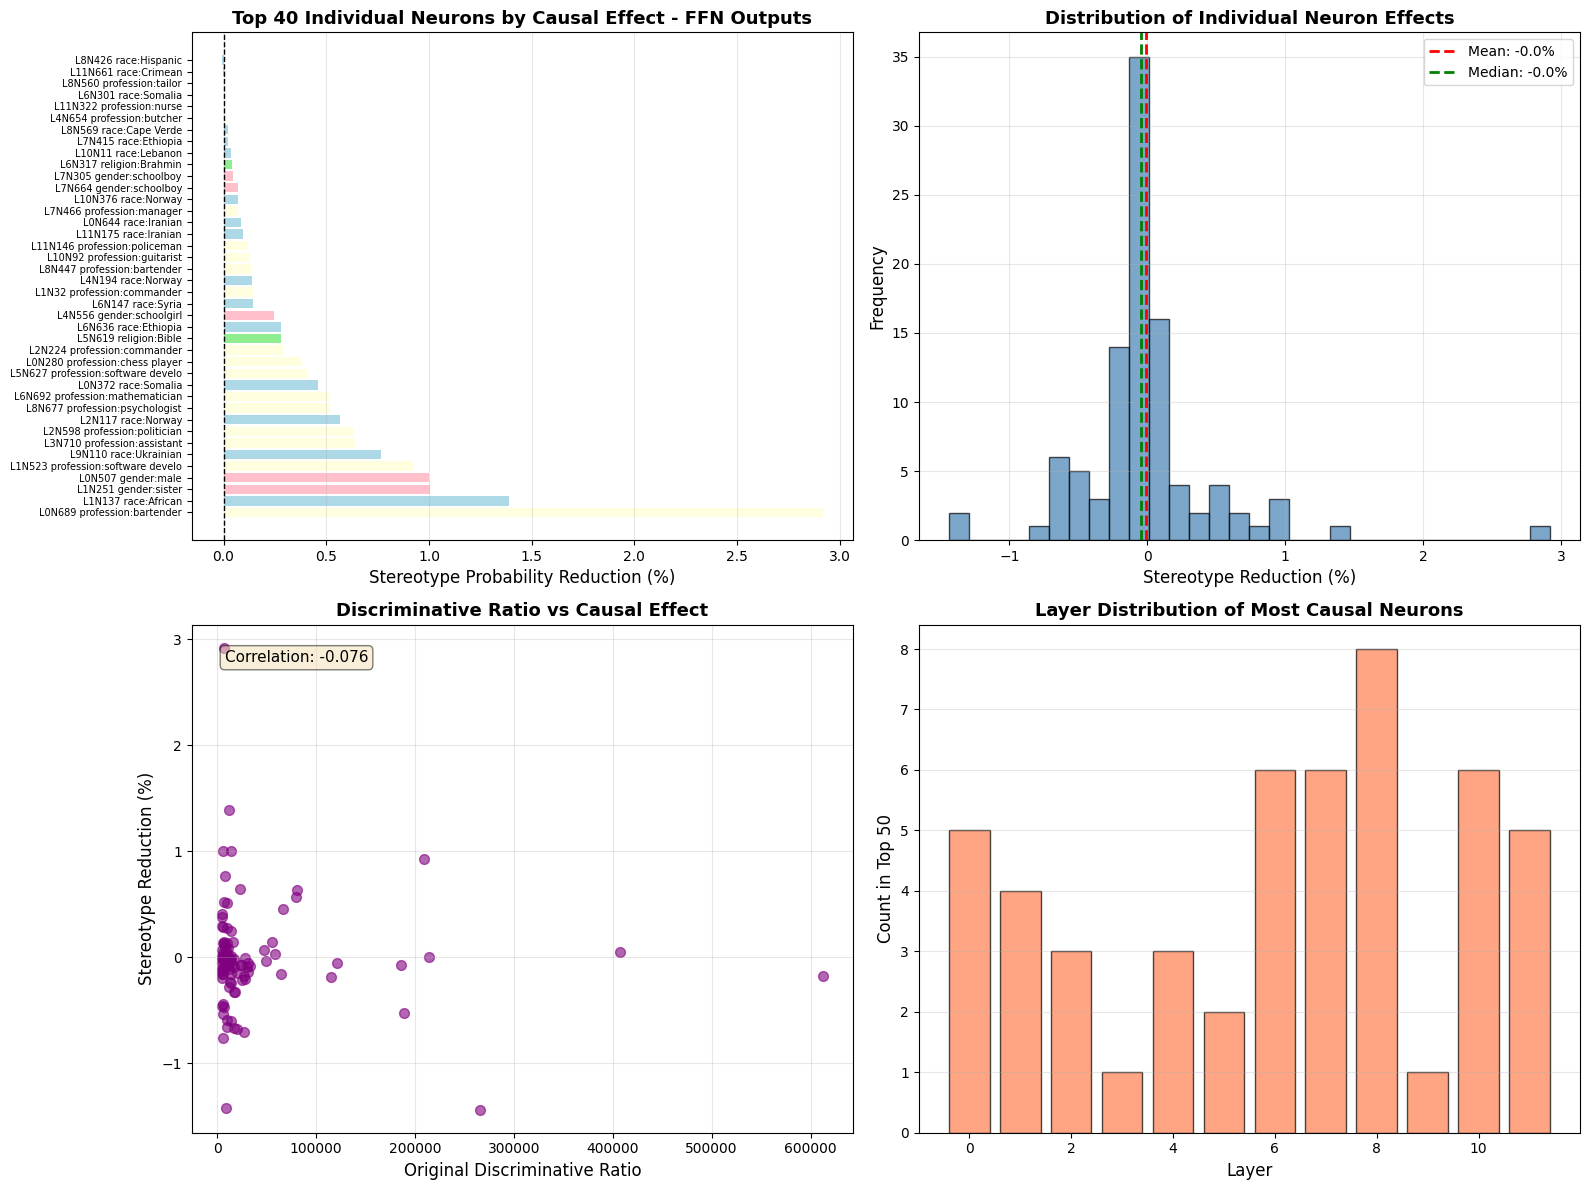


Visualization saved to individual_ffn_ablation.png

INDIVIDUAL NEURON ABLATION SUMMARY - FFN Outputs
Total neurons tested: 100
Mean causal effect: -0.01%
Median causal effect: -0.05%
Std deviation: 0.51%
Max causal effect: 2.92%
Min causal effect: -1.44%

Neurons with >10% reduction: 0
Neurons with >25% reduction: 0
Neurons with >50% reduction: 0
Neurons with negative effect (increased stereotype): 62

Correlation between discriminative ratio and causal effect: -0.076

TOP 10 MOST CAUSAL NEURONS
1. Layer 0, Neuron 689
   Bias: profession, Target: bartender
   Original ratio: 6647.5190
   Stereotype reduction: 2.92%
   Baseline: 0.3468 → Ablated: 0.3366

2. Layer 1, Neuron 137
   Bias: race, Target: African
   Original ratio: 11737.0059
   Stereotype reduction: 1.39%
   Baseline: 0.2536 → Ablated: 0.2501

3. Layer 1, Neuron 251
   Bias: gender, Target: sister
   Original ratio: 6450.0566
   Stereotype reduction: 1.01%
   Baseline: 0.2955 → Ablated: 0.2925

4. Layer 0, Neuron 507
   Bia

Testing neurons: 100%|██████████| 100/100 [03:24<00:00,  2.05s/it]


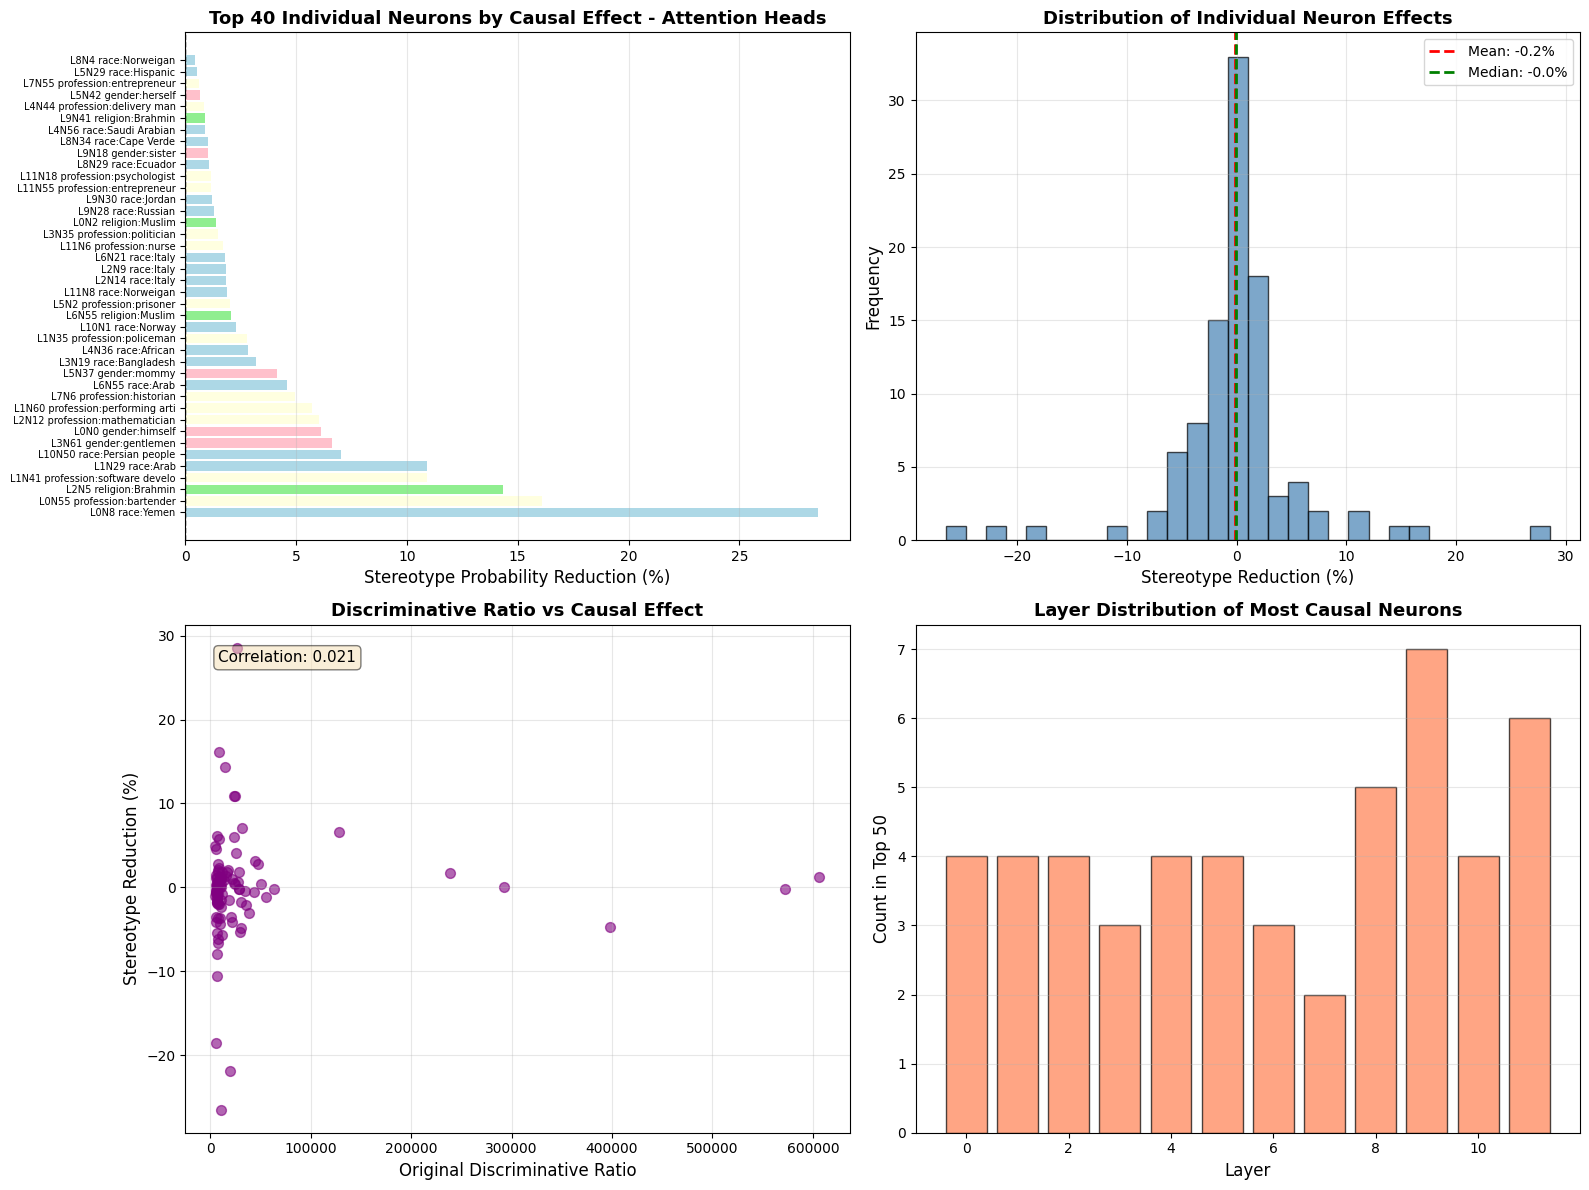


Visualization saved to individual_mha_ablation.png

INDIVIDUAL NEURON ABLATION SUMMARY - Attention Heads
Total neurons tested: 100
Mean causal effect: -0.16%
Median causal effect: -0.01%
Std deviation: 6.27%
Max causal effect: 28.55%
Min causal effect: -26.49%

Neurons with >10% reduction: 5
Neurons with >25% reduction: 1
Neurons with >50% reduction: 0
Neurons with negative effect (increased stereotype): 50

Correlation between discriminative ratio and causal effect: 0.021

TOP 10 MOST CAUSAL NEURONS
1. Layer 0, Neuron 8
   Bias: race, Target: Yemen
   Original ratio: 26584.2695
   Stereotype reduction: 28.55%
   Baseline: 0.4102 → Ablated: 0.2931

2. Layer 0, Neuron 55
   Bias: profession, Target: bartender
   Original ratio: 8954.1055
   Stereotype reduction: 16.10%
   Baseline: 0.3468 → Ablated: 0.2909

3. Layer 2, Neuron 5
   Bias: religion, Target: Brahmin
   Original ratio: 14730.0352
   Stereotype reduction: 14.35%
   Baseline: 0.3540 → Ablated: 0.3032

4. Layer 1, Neuron 41
  

In [ ]:
# ============ INDIVIDUAL NEURON ABLATION EXPERIMENT ============

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def run_individual_neuron_ablation(llm_analyzer, all_neurons_global, activation_type,
                                   stereotypes_dict, model_name='gpt2',
                                   top_n=100, max_examples_per_target=100):
    """
    Test each individual top neuron's causal effect on stereotype probability.

    Returns:
        list of dicts with results for each neuron tested
    """
    # Get top N neurons
    sorted_neurons = sorted(
        all_neurons_global[activation_type],
        key=lambda x: x['ratio'],
        reverse=True
    )[:top_n]

    print(f"\nTesting {len(sorted_neurons)} individual neurons from {activation_type}")
    print(f"{'='*80}\n")

    neuron_results = []

    # Test each neuron individually
    for neuron_idx, neuron in enumerate(tqdm(sorted_neurons, desc="Testing neurons")):
        bias_type = neuron['bias']
        target = neuron['target']

        # Extract layer and feature info based on activation type
        if activation_type == 'ffn_outputs':
            layer_key = neuron['layer']
            if isinstance(layer_key, str) and layer_key.startswith('layer_'):
                layer_idx = int(layer_key.split('_')[1])
            else:
                layer_idx = layer_key
            feature_idx = neuron['feature_idx']
            head_idx = None

        elif activation_type == 'attention_heads':
            layer_idx = neuron['layer']
            head_idx = neuron['head']
            feature_idx = neuron['feature_idx']

        else:  # textual_embeddings
            continue  # Skip embeddings for now as they can't be ablated during forward pass

        # Get examples for this bias/target
        try:
            examples = stereotypes_dict[bias_type][target]
            examples_to_test = examples[:max_examples_per_target]

            baseline_stereo_probs = []
            ablated_stereo_probs = []
            baseline_ppls = []
            ablated_ppls = []

            for example in examples_to_test:
                context = example['context']
                sentences = example['sentences']
                labels = example['labels']

                context_before, context_after, candidates = llm_analyzer.make_prompt(context, sentences)
                if context_before is None:
                    continue

                # === BASELINE (no ablation) ===
                llm_analyzer.clear_all_ablations()
                baseline_likelihoods = llm_analyzer.get_candidate_likelihoods(context_before, candidates)

                # Convert to probabilities
                baseline_probs = np.exp(baseline_likelihoods)
                baseline_probs = baseline_probs / baseline_probs.sum()

                # Calculate stereotype probability
                stereo_prob = sum(baseline_probs[i] for i, label in enumerate(labels) if label == 1)
                baseline_stereo_probs.append(stereo_prob)


                # === BASELINE PERPLEXITY ===
                baseline_ppl = np.exp(-baseline_likelihoods.mean()) if len(baseline_likelihoods) > 0 else np.nan # Handle empty likelihoods
                baseline_ppls.append(baseline_ppl)

                # === ABLATE THIS SINGLE NEURON ===
                llm_analyzer.clear_all_ablations()

                if activation_type == 'ffn_outputs':
                    # Ablate single FFN neuron
                    llm_analyzer.register_ffn_ablation(layer_idx, [feature_idx], method='zero')

                elif activation_type == 'attention_heads':
                    # Ablate single attention head (all neurons in head)
                    head_dim = llm_analyzer.model.config.n_embd // llm_analyzer.model.config.n_head
                    all_neuron_indices_in_head = list(range(head_dim))
                    llm_analyzer.register_mha_ablation(layer_idx, head_idx, all_neuron_indices_in_head, method='zero')

                # Get ablated likelihoods
                ablated_likelihoods = llm_analyzer.get_candidate_likelihoods(context_before, candidates)

                # Convert to probabilities
                ablated_probs = np.exp(ablated_likelihoods)
                ablated_probs = ablated_probs / ablated_probs.sum()

                # Calculate stereotype probability
                stereo_prob_ablated = sum(ablated_probs[i] for i, label in enumerate(labels) if label == 1)
                ablated_stereo_probs.append(stereo_prob_ablated)


                # === ABLATED PERPLEXITY ===
                ablated_ppl = np.exp(-ablated_likelihoods.mean()) if len(ablated_likelihoods) > 0 else np.nan # Handle empty likelihoods
                ablated_ppls.append(ablated_ppl)

            # Calculate statistics for this neuron
            if baseline_stereo_probs and not np.isnan(baseline_ppls).all(): # Ensure there are valid baseline probabilities and PPLs
                mean_baseline = np.mean(baseline_stereo_probs)
                mean_ablated = np.mean(ablated_stereo_probs)

                reduction_percent = ((mean_baseline - mean_ablated) / mean_baseline * 100) if mean_baseline != 0 else 0
                absolute_reduction = mean_baseline - mean_ablated

                neuron_result = {
                    'neuron_rank': neuron_idx + 1,
                    'bias_type': bias_type,
                    'target': target,
                    'layer': layer_idx,
                    'feature_idx': feature_idx,
                    'head_idx': head_idx,
                    'original_ratio': neuron['ratio'],
                    'mean_baseline_stereo': mean_baseline,
                    'mean_ablated_stereo': mean_ablated,
                    'reduction_percent': reduction_percent,
                    'absolute_reduction': absolute_reduction,
                    'num_examples': len(baseline_stereo_probs),
                    'activation_type': activation_type,
                    'mean_baseline_ppl': np.nanmean(baseline_ppls), # Use nanmean to ignore NaNs
                    'mean_ablated_ppl': np.nanmean(ablated_ppls),   # Use nanmean to ignore NaNs
                    'ppl_change': np.nanmean(ablated_ppls) - np.nanmean(baseline_ppls) # Use nanmean to ignore NaNs
                }

                neuron_results.append(neuron_result)

        except Exception as e:
            print(f"\nError testing neuron {neuron_idx + 1}: {e}")
            continue

    # Clear ablations when done
    llm_analyzer.clear_all_ablations()

    return neuron_results

def visualize_individual_neuron_results(neuron_results, activation_type, save_path='individual_neuron_ablation.png'):
    """
    Visualize results of individual neuron ablation experiments.
    """
    if not neuron_results:
        print("No results to visualize!")
        return

    # Sort by reduction
    sorted_results = sorted(neuron_results, key=lambda x: x['reduction_percent'], reverse=True)

    # Extract data
    reductions = [r['reduction_percent'] for r in neuron_results]
    original_ratios = [r['original_ratio'] for r in neuron_results]
    layers = [r['layer'] for r in neuron_results]
    bias_types = [r['bias_type'] for r in neuron_results]

    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Top neurons by causal effect
    top_n = min(40, len(sorted_results))
    top_results = sorted_results[:top_n]

    colors_map = {'gender': 'pink', 'race': 'lightblue', 'religion': 'lightgreen', 'profession': 'lightyellow'}
    bar_colors = [colors_map.get(r['bias_type'], 'gray') for r in top_results]

    labels = []
    for r in top_results:
        if activation_type == 'attention_heads':
            labels.append(f"L{r['layer']}H{r['head_idx']} {r['bias_type']}:{r['target'][:15]}")
        else:
            labels.append(f"L{r['layer']}N{r['feature_idx']} {r['bias_type']}:{r['target'][:15]}")

    axes[0, 0].barh(range(top_n), [r['reduction_percent'] for r in top_results], color=bar_colors)
    axes[0, 0].set_yticks(range(top_n))
    axes[0, 0].set_yticklabels(labels, fontsize=7)
    axes[0, 0].set_xlabel('Stereotype Probability Reduction (%)', fontsize=12)
    axes[0, 0].set_title(f'Top {top_n} Individual Neurons by Causal Effect - {activation_type}',
                         fontsize=13, fontweight='bold')
    axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].grid(axis='x', alpha=0.3)

    # Plot 2: Distribution of causal effects
    axes[0, 1].hist(reductions, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 1].axvline(x=np.mean(reductions), color='red', linestyle='--',
                       linewidth=2, label=f'Mean: {np.mean(reductions):.1f}%')
    axes[0, 1].axvline(x=np.median(reductions), color='green', linestyle='--',
                       linewidth=2, label=f'Median: {np.median(reductions):.1f}%')
    axes[0, 1].set_xlabel('Stereotype Reduction (%)', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Distribution of Individual Neuron Effects', fontsize=13, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Plot 3: Correlation between discriminative ratio and causal effect
    axes[1, 0].scatter(original_ratios, reductions, alpha=0.6, s=50, color='purple')
    axes[1, 0].set_xlabel('Original Discriminative Ratio', fontsize=12)
    axes[1, 0].set_ylabel('Stereotype Reduction (%)', fontsize=12)
    axes[1, 0].set_title('Discriminative Ratio vs Causal Effect', fontsize=13, fontweight='bold')
    axes[1, 0].grid(alpha=0.3)

    # Add correlation coefficient
    correlation = np.corrcoef(original_ratios, reductions)[0, 1] if len(original_ratios) > 1 else np.nan # Handle case with too few data points
    axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}',
                    transform=axes[1, 0].transAxes, fontsize=11, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Plot 4: Layer distribution of top causal neurons
    from collections import Counter
    layer_counter = Counter([r['layer'] for r in sorted_results[:50]])

    layers_sorted = sorted(layer_counter.keys())
    layer_counts = [layer_counter[l] for l in layers_sorted]

    axes[1, 1].bar(layers_sorted, layer_counts, color='coral', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Layer', fontsize=12)
    axes[1, 1].set_ylabel('Count in Top 50', fontsize=12)
    axes[1, 1].set_title('Layer Distribution of Most Causal Neurons', fontsize=13, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nVisualization saved to {save_path}")

    # Print summary statistics
    print(f"\n{'='*80}")
    print(f"INDIVIDUAL NEURON ABLATION SUMMARY - {activation_type}")
    print(f"{'='*80}")
    print(f"Total neurons tested: {len(neuron_results)}")
    print(f"Mean causal effect: {np.mean(reductions):.2f}%")
    print(f"Median causal effect: {np.median(reductions):.2f}%")
    print(f"Std deviation: {np.std(reductions):.2f}%")
    print(f"Max causal effect: {np.max(reductions):.2f}%")
    print(f"Min causal effect: {np.min(reductions):.2f}%")
    print(f"\nNeurons with >10% reduction: {sum(1 for r in reductions if r > 10)}")
    print(f"Neurons with >25% reduction: {sum(1 for r in reductions if r > 25)}")
    print(f"Neurons with >50% reduction: {sum(1 for r in reductions if r > 50)}")
    print(f"Neurons with negative effect (increased stereotype): {sum(1 for r in reductions if r < 0)}")

    print(f"\nCorrelation between discriminative ratio and causal effect: {correlation:.3f}")

    # Print top 10 most causal neurons
    print(f"\n{'='*80}")
    print("TOP 10 MOST CAUSAL NEURONS")
    print(f"{'='*80}")
    for i, result in enumerate(sorted_results[:10], 1):
        if activation_type == 'attention_heads':
            print(f"{i}. Layer {result['layer']}, Head {result['head_idx']}")
        else:
            print(f"{i}. Layer {result['layer']}, Neuron {result['feature_idx']}")
        print(f"   Bias: {result['bias_type']}, Target: {result['target']}")
        print(f"   Original ratio: {result['original_ratio']:.4f}")
        print(f"   Stereotype reduction: {result['reduction_percent']:.2f}%")
        print(f"   Baseline: {result['mean_baseline_stereo']:.4f} → Ablated: {result['mean_ablated_stereo']:.4f}")
        print()

    # Extract all PPL changes
    ppl_changes = [r['ppl_change'] for r in neuron_results]

    print(f"\n{'='*80}")
    print(f"PERPLEXITY CHANGE SUMMARY - {activation_type}")
    print(f"{'='*80}")
    print(f"Mean PPL change (Ablated - Baseline): {np.nanmean(ppl_changes):.4f}") # Use nanmean
    print(f"Median PPL change: {np.nanmedian(ppl_changes):.4f}") # Use nanmedian
    print(f"Max PPL change: {np.nanmax(ppl_changes):.4f}") # Use nanmax
    print(f"Min PPL change: {np.nanmin(ppl_changes):.4f}") # Use nanmin

# ============ MAIN EXECUTION ============

print("Starting Individual Neuron Ablation Experiments...")
print("="*80)

# Test FFN neurons individually
print("\n### TESTING INDIVIDUAL FFN NEURONS ###\n")
llm_analyzer = LLMAnalyzer(model_name="gpt2") # Re-initialize llm_analyzer here to ensure updated class definition
ffn_neuron_results = run_individual_neuron_ablation(
    llm_analyzer,
    all_neurons_global,
    'ffn_outputs',
    stereotypes_dict,
    top_n=100,  # Test top 100 neurons
    max_examples_per_target=100  # Use 5 examples per target for speed
)

visualize_individual_neuron_results(
    ffn_neuron_results,
    'FFN Outputs',
    'individual_ffn_ablation.png'
)

# Test attention heads individually
print("\n### TESTING INDIVIDUAL ATTENTION HEADS ###\n")
mha_neuron_results = run_individual_neuron_ablation(
    llm_analyzer,
    all_neurons_global,
    'attention_heads',
    stereotypes_dict,
    top_n=100,  # Test top 100 heads
    max_examples_per_target=100
)

visualize_individual_neuron_results(
    mha_neuron_results,
    'Attention Heads',
    'individual_mha_ablation.png'
)

# Compare which has stronger individual effects
print("\n\n### COMPARISON: FFN vs ATTENTION HEAD INDIVIDUAL EFFECTS ###\n")
ffn_effects = [r['reduction_percent'] for r in ffn_neuron_results]
mha_effects = [r['reduction_percent'] for r in mha_neuron_results]

if ffn_effects:
    print(f"FFN - Mean individual neuron effect: {np.mean(ffn_effects):.2f}%")
    print(f"FFN - Max individual effect: {np.max(ffn_effects):.2f}%")
else:
    print("No FFN effects to compute mean/max.")

if mha_effects:
    print(f"MHA - Mean individual head effect: {np.mean(mha_effects):.2f}%")
    print(f"MHA - Max individual effect: {np.max(mha_effects):.2f}%")
else:
    print("No MHA effects to compute mean/max.")

if ffn_effects and mha_effects:
    if np.mean(ffn_effects) > np.mean(mha_effects):
        print(f"\nFFN neurons have stronger individual causal effects on average")
    else:
        print(f"\nAttention heads have stronger individual causal effects on average")
else:
    print("\nCannot compare FFN and MHA effects due to insufficient data.")

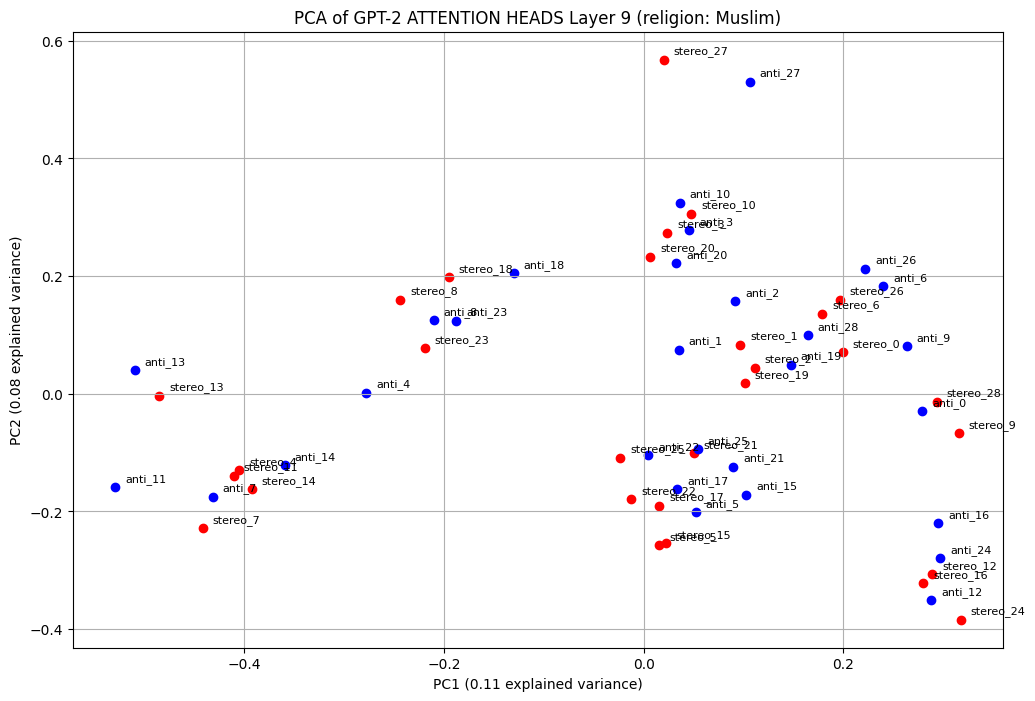

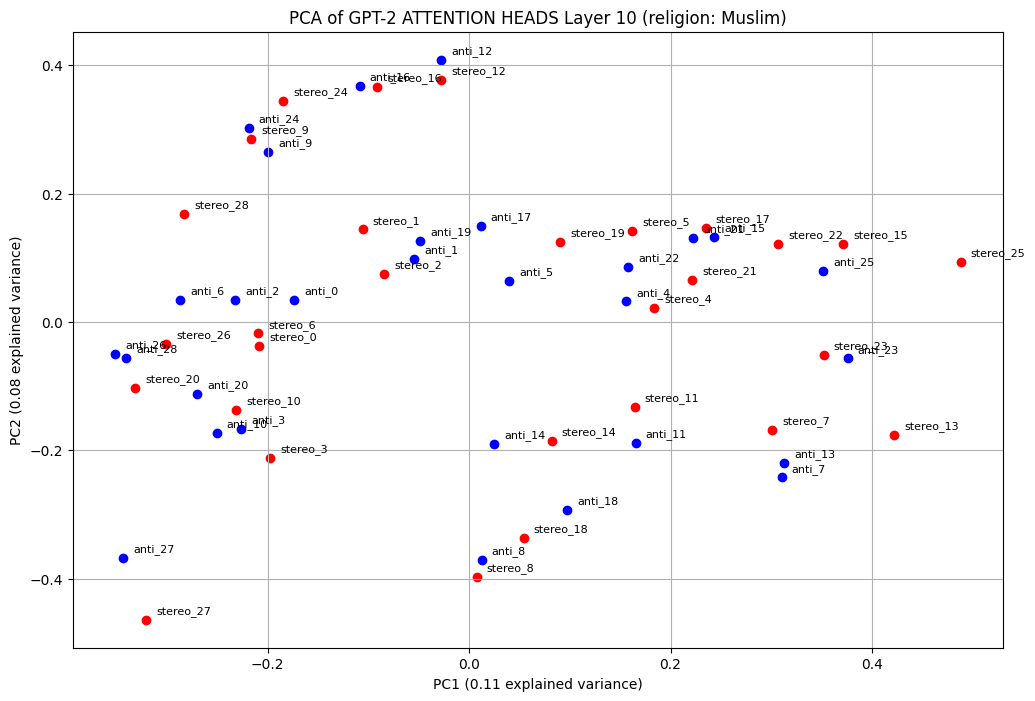

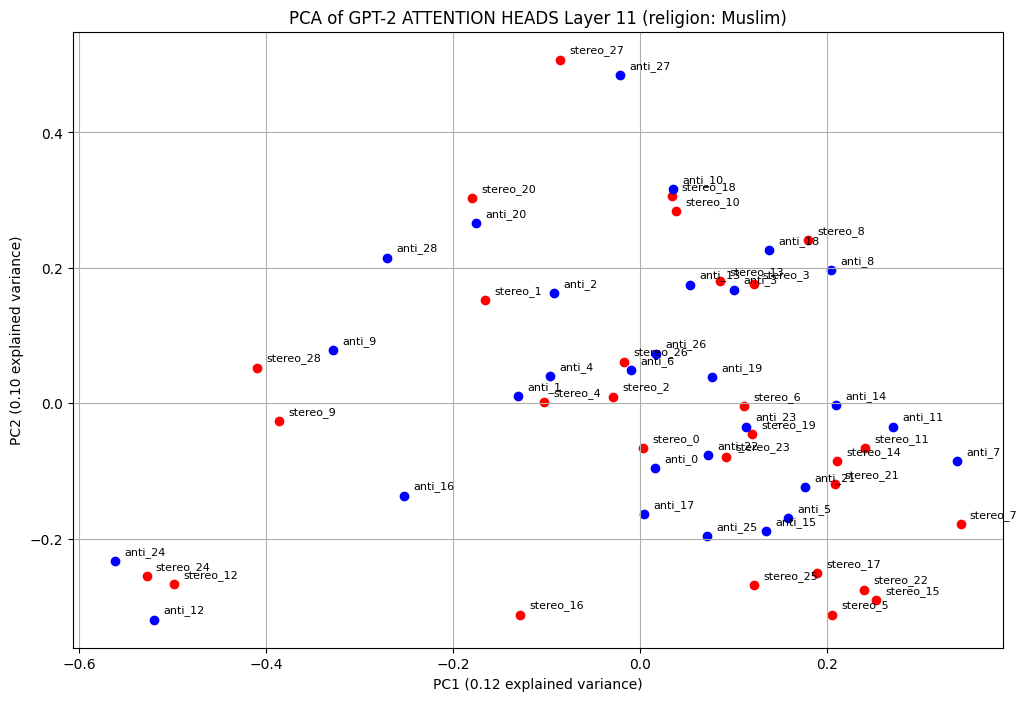

In [ ]:
#just playing around seeing if activations are separable with pca potentially a stereotype direction

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

act_type = 'attention_heads'  # or 'attention_heads' / 'textual_embeddings'
bias_type = 'religion'
target = 'Muslim'
num_last_layers = 3  # how many top layers to plot

# Get activations
stereo_acts = results_by_model['gpt2'][act_type][bias_type][target].get('stereotype', [])
antistereo_acts = results_by_model['gpt2'][act_type][bias_type][target].get('antistereotype', [])

if act_type != 'textual_embeddings':
    example_act = stereo_acts[0] if stereo_acts else antistereo_acts[0]
    total_layers = example_act.shape[0]
    layers_to_plot = range(total_layers - num_last_layers, total_layers)
else:
    layers_to_plot = [0]

for layer_idx in layers_to_plot:
    X_layer = []
    labels_layer = []

    # Flatten activations per layer
    if act_type == 'attention_heads':
        stereo_layer = [act[layer_idx].flatten() for act in stereo_acts]
        antistereo_layer = [act[layer_idx].flatten() for act in antistereo_acts]
    elif act_type == 'ffn_outputs':
        stereo_layer = [act[layer_idx] for act in stereo_acts]
        antistereo_layer = [act[layer_idx] for act in antistereo_acts]
    else:  # textual embeddings
        stereo_layer = stereo_acts
        antistereo_layer = antistereo_acts

    # Append all examples individually
    X_layer.extend(stereo_layer)
    labels_layer.extend([f"stereo_{i}" for i in range(len(stereo_layer))])

    X_layer.extend(antistereo_layer)
    labels_layer.extend([f"anti_{i}" for i in range(len(antistereo_layer))])

    if not X_layer:
        continue

    X_layer = np.stack(X_layer)
    X_norm = X_layer / np.linalg.norm(X_layer, axis=1, keepdims=True)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_norm)

    # Plot
    plt.figure(figsize=(12, 8))
    for i, label in enumerate(labels_layer):
        x, y = X_pca[i]
        color = 'red' if 'stereo' in label else 'blue'
        plt.scatter(x, y, color=color)
        plt.text(x + 0.01, y + 0.01, label, fontsize=8)

    plt.title(f"PCA of GPT-2 {act_type.replace('_', ' ').upper()} Layer {layer_idx} (religion: Muslim)")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2f} explained variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2f} explained variance)")
    plt.grid(True)
    plt.show()


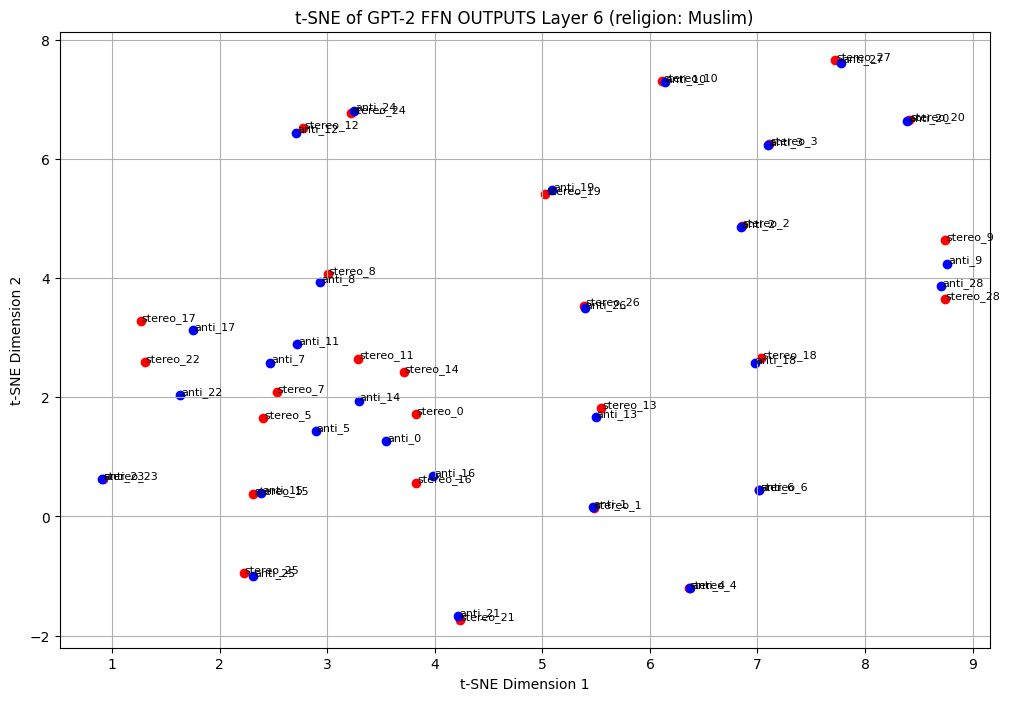

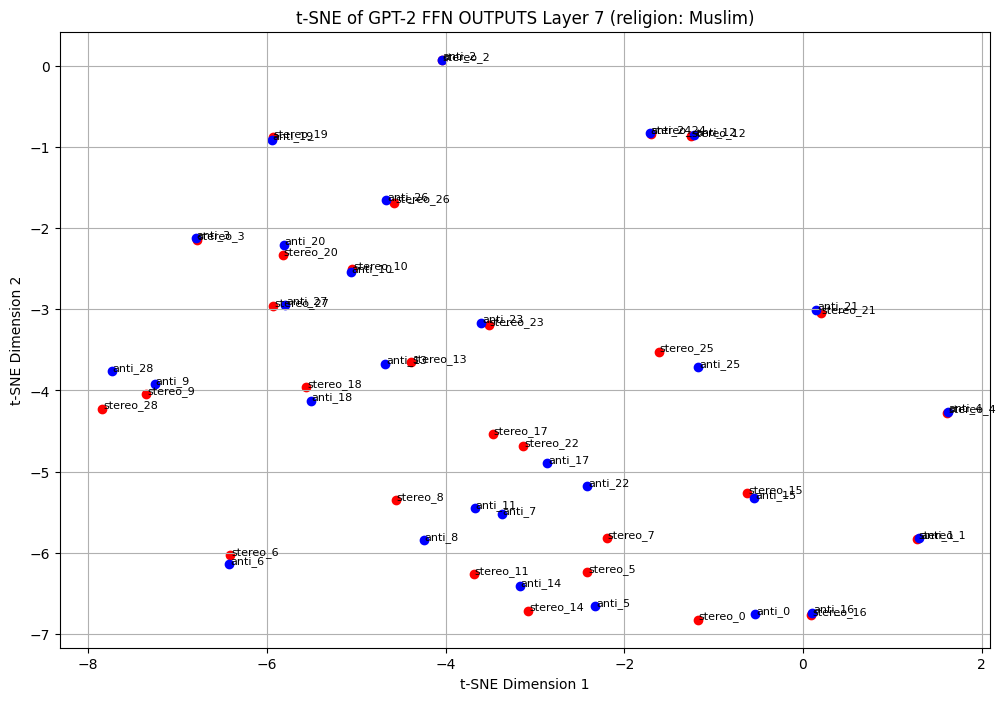

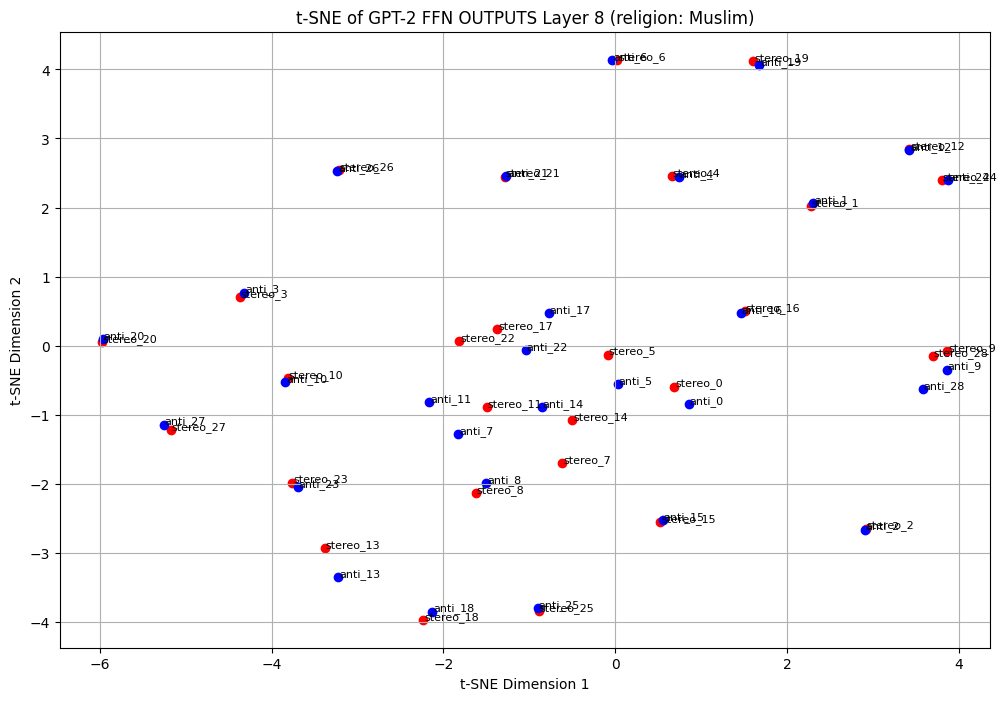

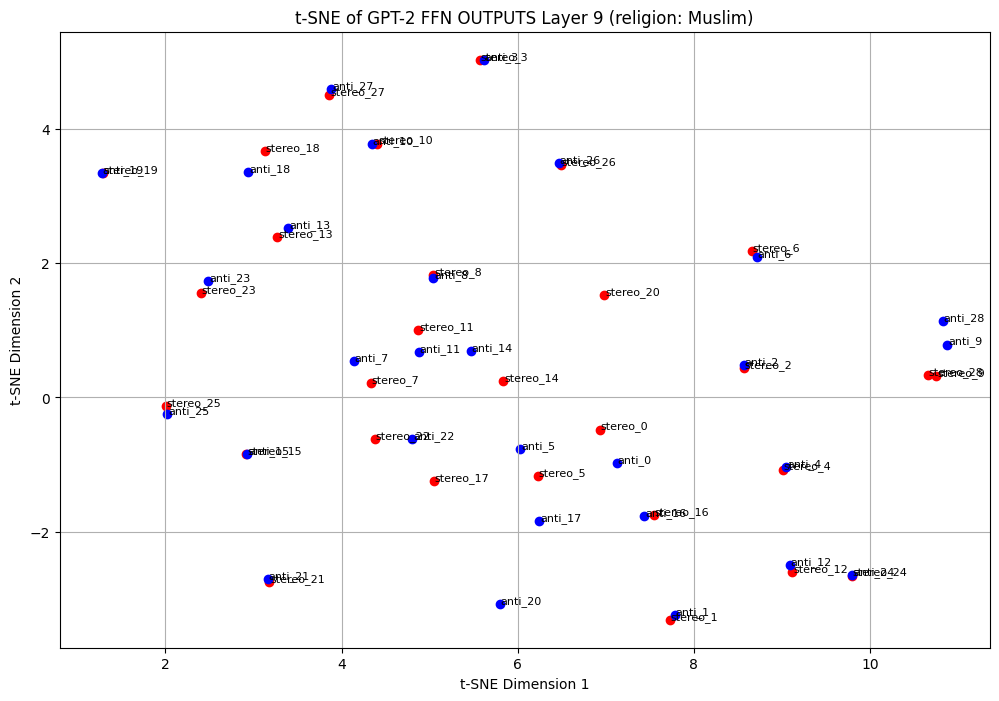

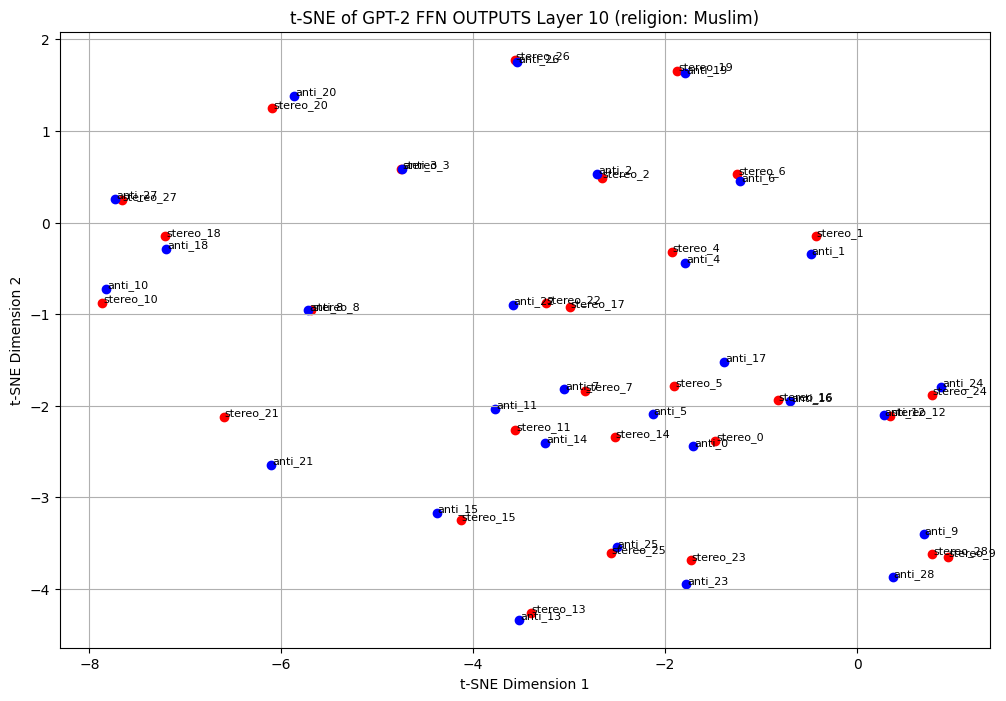

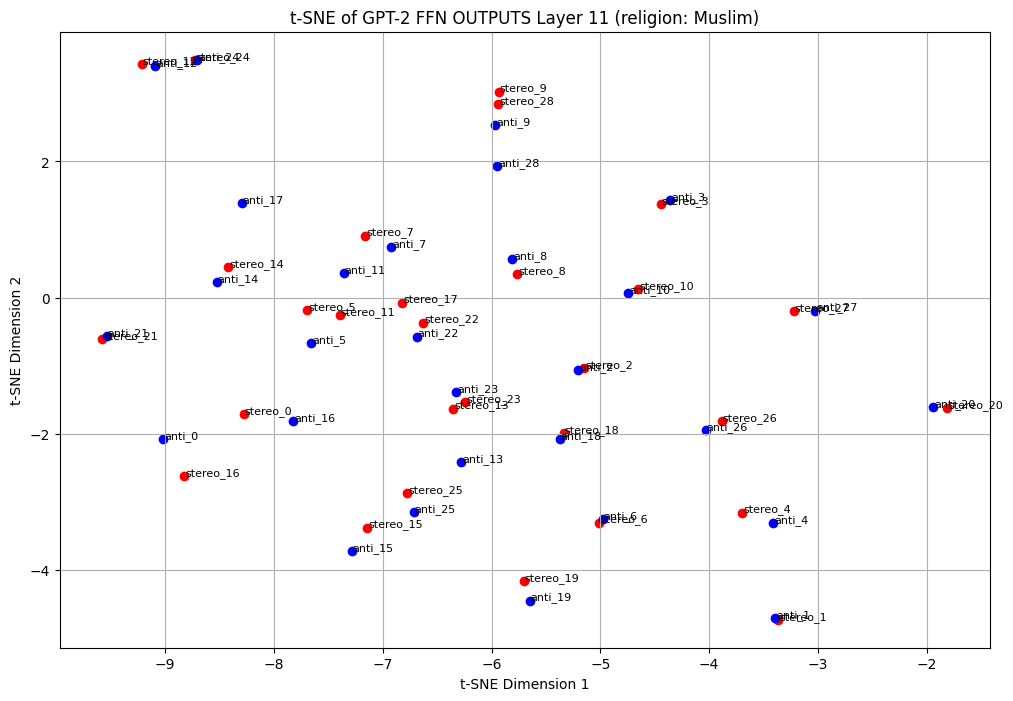

In [ ]:
#just playing around seeing if activations are separable with tsne potentially a stereotype direction

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE  # Change this import

act_type = 'ffn_outputs'  # or 'attention_heads' / 'textual_embeddings / ffn_outputs'
bias_type = 'religion'
target = 'Muslim'
num_last_layers = 6  # how many top layers to plot

# Get activations
stereo_acts = results_by_model['gpt2'][act_type][bias_type][target].get('stereotype', [])
antistereo_acts = results_by_model['gpt2'][act_type][bias_type][target].get('antistereotype', [])

if act_type != 'textual_embeddings':
    example_act = stereo_acts[0] if stereo_acts else antistereo_acts[0]
    total_layers = example_act.shape[0]
    layers_to_plot = range(total_layers - num_last_layers, total_layers)
else:
    layers_to_plot = [0]

for layer_idx in layers_to_plot:
    X_layer = []
    labels_layer = []

    # Flatten activations per layer
    if act_type == 'attention_heads':
        stereo_layer = [act[layer_idx].flatten() for act in stereo_acts]
        antistereo_layer = [act[layer_idx].flatten() for act in antistereo_acts]
    elif act_type == 'ffn_outputs':
        stereo_layer = [act[layer_idx] for act in stereo_acts]
        antistereo_layer = [act[layer_idx] for act in antistereo_acts]
    else:  # textual embeddings
        stereo_layer = stereo_acts
        antistereo_layer = antistereo_acts

    # Append all examples individually
    X_layer.extend(stereo_layer)
    labels_layer.extend([f"stereo_{i}" for i in range(len(stereo_layer))])

    X_layer.extend(antistereo_layer)
    labels_layer.extend([f"anti_{i}" for i in range(len(antistereo_layer))])

    if not X_layer:
        continue

    X_layer = np.stack(X_layer)
    X_norm = X_layer / np.linalg.norm(X_layer, axis=1, keepdims=True)

    # t-SNE instead of PCA
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_norm)-1))
    X_tsne = tsne.fit_transform(X_norm)

    # Plot
    plt.figure(figsize=(12, 8))
    for i, label in enumerate(labels_layer):
        x, y = X_tsne[i]
        color = 'red' if 'stereo' in label else 'blue'
        plt.scatter(x, y, color=color)
        plt.text(x + 0.01, y + 0.01, label, fontsize=8)

    plt.title(f"t-SNE of GPT-2 {act_type.replace('_', ' ').upper()} Layer {layer_idx} (religion: Muslim)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True)
    plt.show()